In [104]:
# 5-1 Regression

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from scipy import stats
from sklearn.datasets import fetch_california_housing

import warnings
warnings.filterwarnings("ignore")

housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns = housing.feature_names)
df["PRICE"] = housing.target

print(df.shape)
df.head()

(20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


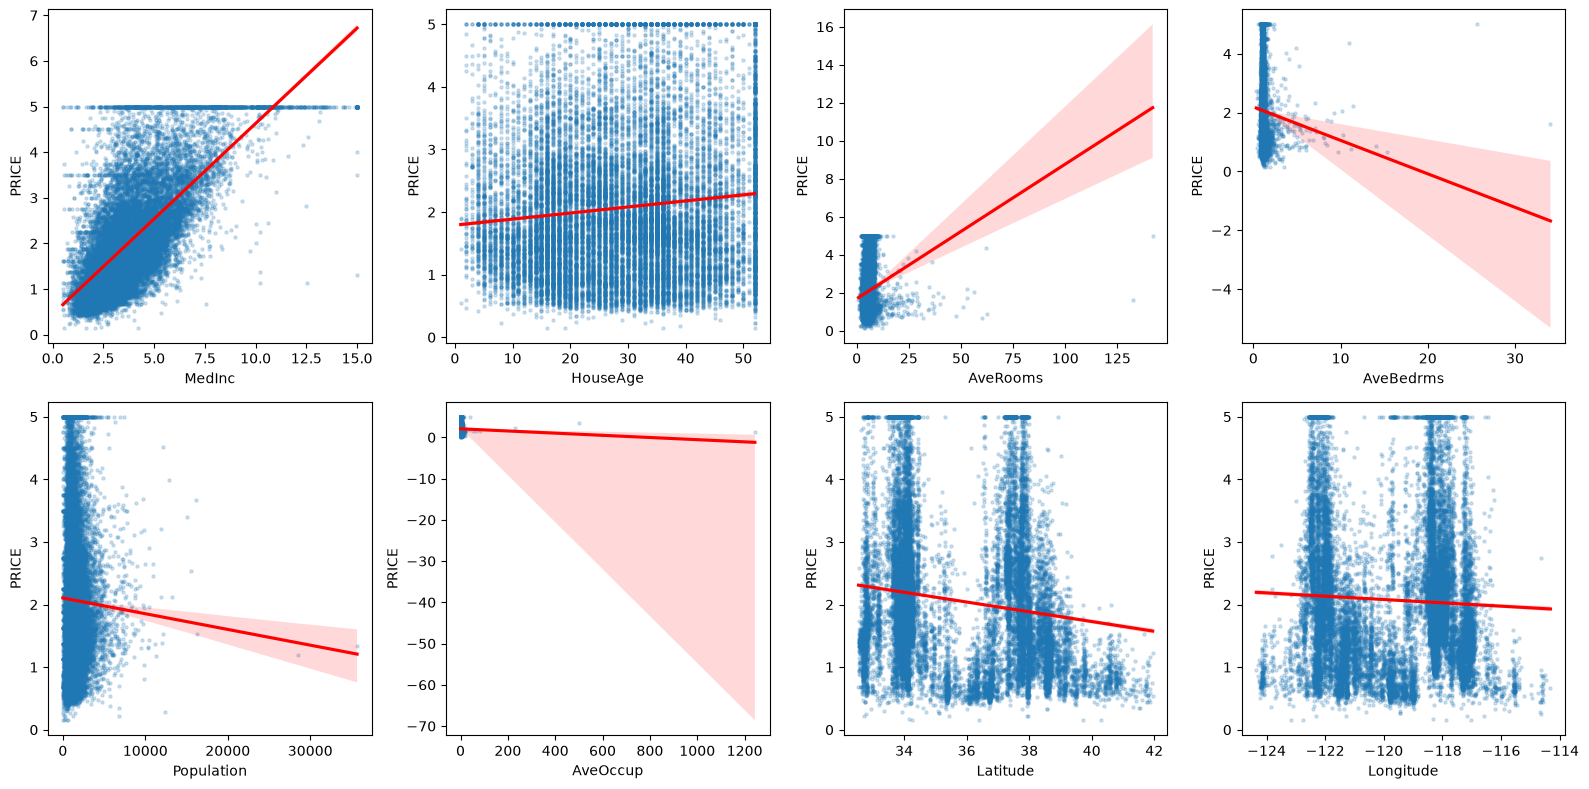

In [105]:
# 그려보고 확인하고 넘어가는게 좋음(EDA 데이터 탐색)
fig, axs = plt.subplots(figsize = (16, 8), ncols = 4, nrows = 2)
lm_features = ["MedInc", "HouseAge", "AveRooms", "AveBedrms", "Population", "AveOccup", "Latitude", "Longitude"]

for i, feature in enumerate(lm_features):
    row = int(i / 4)
    col = i % 4

    sns.regplot(x = feature, y = "PRICE", data = df, ax = axs[row][col], 
                scatter_kws = {"s": 5, "alpha": 0.2, }, line_kws = {"color": "red"})

plt.tight_layout()
fig1 = plt.gcf()

In [106]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

y_target = df["PRICE"]
X_data = df.drop(["PRICE"], axis = 1, inplace = False)

X_train, X_test, y_train, y_test = train_test_split(X_data, y_target, test_size = 0.3, random_state = 42)

lr = LinearRegression()
lr.fit(X_train, y_train)
pred = lr.predict(X_test)
print(pred) # 예측한 집값이 나옴
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)

print(mse)
print(rmse)
print(r2_score(y_test, pred))

[0.72604907 1.76743383 2.71092161 ... 2.07465531 1.57371395 1.82744133]
0.530567782476675
0.7284008391515451
0.5957702326061665


In [107]:
# 절편, 회귀계수 구하기
print(lr.intercept_)
print(np.around(lr.coef_, 3))

-37.0562413315252
[ 0.446  0.01  -0.122  0.779 -0.    -0.003 -0.419 -0.434]


In [108]:
# 회귀계수를 큰 순서대로 정렬

coeff = pd.Series(data = np.round(lr.coef_, 3), index = X_data.columns)
coeff.sort_values(ascending=False)

AveBedrms     0.779
MedInc        0.446
HouseAge      0.010
Population   -0.000
AveOccup     -0.003
AveRooms     -0.122
Latitude     -0.419
Longitude    -0.434
dtype: float64

In [109]:
# Cross validation score

from sklearn.model_selection import cross_val_score

y_target = df["PRICE"]
X_data = df.drop(['PRICE'], axis = 1, inplace = False)

lr = LinearRegression()

# 회귀에선 neg_mean_squared_error를 사용
neg_mse_scores = cross_val_score(lr, X_data, y_target, scoring = "neg_mean_squared_error", cv = 5)

rmse_scores = np.sqrt(-1 * neg_mse_scores)
avg_rmse = np.mean(rmse_scores)

print(np.round(neg_mse_scores, 2))
print(np.round(rmse_scores, 2))
print(avg_rmse)

[-0.48 -0.62 -0.65 -0.54 -0.49]
[0.7  0.79 0.8  0.74 0.7 ]
0.7459068363518113


In [110]:
# 다항 회귀

from sklearn.preprocessing import PolynomialFeatures
import numpy as np

X = np.arange(4).reshape(2, 2)
print("일차 단항식 계수:", X)

poly = PolynomialFeatures(degree = 2)
poly.fit(X)
poly_ftr = poly.transform(X)
print("변환된 2차 다항식 계수:", poly_ftr)

일차 단항식 계수: [[0 1]
 [2 3]]
변환된 2차 다항식 계수: [[1. 0. 1. 0. 0. 1.]
 [1. 2. 3. 4. 6. 9.]]


In [111]:
# 3차 다항식 함수 만들기

def polynomial_func(X):
    y = 1 + 2 * X[:, 0] + 3 * X[:, 0] ** 2 + 4 * X[:, 1] ** 3

    print(X[:, 0])
    print(X[:, 1])

    return y


In [112]:
X = np.arange(0, 4).reshape(2, 2)

print("일차 단항식 계수:", X)

y = polynomial_func(X)
print("삼차 다항식 결정값:", y)


일차 단항식 계수: [[0 1]
 [2 3]]
[0 2]
[1 3]
삼차 다항식 결정값: [  5 125]


In [113]:
# 3차 다항식 변환
poly_ftr = PolynomialFeatures(degree = 3).fit_transform(X)
print("3차 다항식 계수:", poly_ftr)

model = LinearRegression()
model.fit(poly_ftr, y)
print("회귀 계수:", np.round(model.coef_, 2))
print("회귀 shape:", model.coef_.shape)

3차 다항식 계수: [[ 1.  0.  1.  0.  0.  1.  0.  0.  0.  1.]
 [ 1.  2.  3.  4.  6.  9.  8. 12. 18. 27.]]
회귀 계수: [0.   0.18 0.18 0.36 0.54 0.72 0.72 1.08 1.62 2.34]
회귀 shape: (10,)


In [114]:
# 파이프라인 할 수 있어야 함. (중요)

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

import numpy as np

def polynomial_func(X):
    y = 2 + 2 * X[:, 0] + 3 * X[:, 0] ** 2 + 4 * X[:, 1] ** 3
    return y

model = Pipeline([("poly", PolynomialFeatures(degree = 3)),
                 ("linear", LinearRegression())
                 ])

X = np.arange(4).reshape(2, 2)
y = polynomial_func(X)

model = model.fit(X, y)
print("회귀 계수:", np.round(model.named_steps["linear"].coef_, 2))

회귀 계수: [0.   0.18 0.18 0.36 0.54 0.72 0.72 1.08 1.62 2.34]


In [115]:
# 과소적합, 과적합

import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

def true_func(X):
    return np.cos(1.5 * np.pi * X)

np.random.seed(0)
n_samples = 30

X = np.sort(np.random.rand(n_samples))
y = true_func(X) + np.random.randn(n_samples) * 0.1


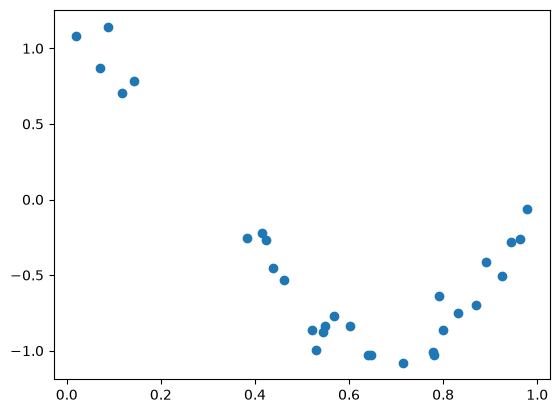

In [116]:
plt.scatter(X, y)

Degree: 1
회귀 계수: [-1.61]
MSE: 0.4077289625098685
Degree: 4
회귀 계수: [  0.47 -17.79  23.59  -7.26]
MSE: 0.04320874987232056
Degree: 15
회귀 계수: [    3.29   -83.83   474.97 -1211.36  1006.92   668.01  -659.73  -935.56
  -134.     746.87   885.29   168.    -810.43  -990.04   871.11]
MSE: 0.21959838159883258


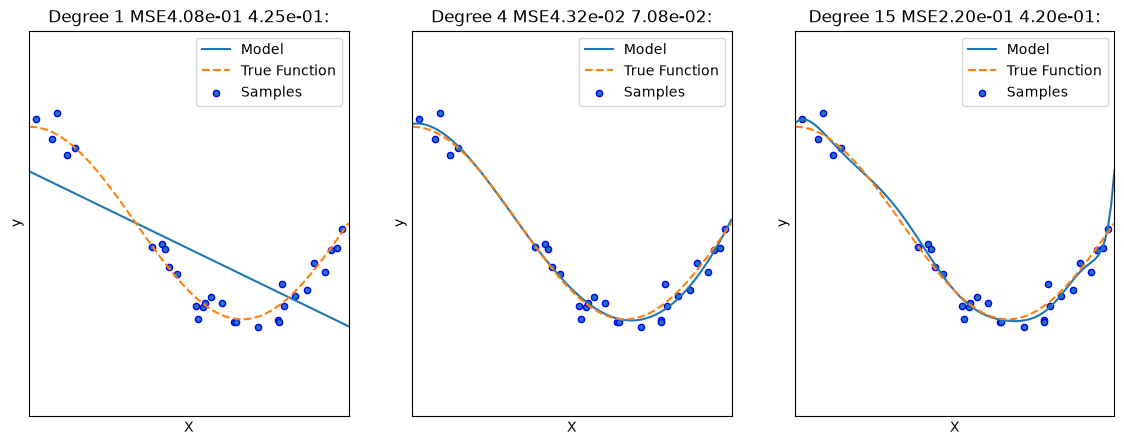

In [117]:
plt.figure(figsize = (14, 5))
degrees = [1, 4, 15]

for i in range(len(degrees)):
    ax = plt.subplot(1, len(degrees), i + 1)
    plt.setp(ax, xticks = (), yticks = ())
    polynomial_features = PolynomialFeatures(degree = degrees[i], include_bias = False)

    linear_regression = LinearRegression()
    pipeline = Pipeline([("polynomial_fatures", polynomial_features),
                         ("linear_regression", linear_regression)  

                         ])

    pipeline.fit(X.reshape(-1, 1), y)

    scores = cross_val_score(pipeline, X.reshape(-1, 1), y, scoring = "neg_mean_squared_error", cv = 10)

    coefficients = pipeline.named_steps["linear_regression"].coef_

    print("Degree:", degrees[i])
    print("회귀 계수:", np.round(coefficients, 2))
    print("MSE:", -1 * np.mean(scores))

    X_test = np.linspace(0, 1, 100)
    plt.plot(X_test, pipeline.predict(X_test[:, np.newaxis]), label = "Model")
    plt.plot(X_test, true_func(X_test), "--", label = "True Function")
    plt.scatter(X, y, edgecolor = "b", s = 20, label = "Samples")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.xlim((0, 1))
    plt.ylim((-2, 2))
    plt.legend(loc = "best")
    plt.title("Degree {} MSE{:.2e} {:.2e}:".format(degrees[i], -scores.mean(), scores.std()))

plt.show()

In [118]:
# 규제
# 영향주는건 살리고, 영향안주는건 버리자 -> 라쏘
# 영향에 따라서 weight를 줌 -> 릿지

from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns = housing.feature_names)

df["PRICE"] = housing.target

y_target = df["PRICE"]
X_data = df.drop("PRICE", axis = 1, inplace = False)

ridge = Ridge(alpha = 10)
neg_mean_scores = cross_val_score(ridge, X_data, y_target, scoring = "neg_mean_squared_error", cv = 5)
rmse_scores = np.sqrt(-1 * neg_mean_scores)
avg_rmse = np.mean(rmse_scores)

print("Negative MSE:", np.round(neg_mse_scores, 3))
print("RMSE:", np.round(rmse_scores, 3))
print("Average RMSE:", avg_rmse)

Negative MSE: [-0.485 -0.622 -0.646 -0.543 -0.495]
RMSE: [0.695 0.789 0.804 0.737 0.703]
Average RMSE: 0.745820729297258


In [119]:
alphas = [0, 0.1, 1, 10, 100]

for alpha in alphas:
    ridge = Ridge(alpha = alpha)

    neg_mse_scores = cross_val_score(ridge, X_data, y_target, scoring = "neg_mean_squared_error", cv = 5)
    avg_rmse = np.mean(np.sqrt(-1 * neg_mse_scores))
    print("alpha {0}, RMSE: {1}".format(alpha, avg_rmse))

alpha 0, RMSE: 0.7459068363518114
alpha 0.1, RMSE: 0.7459058975815243
alpha 1, RMSE: 0.7458975215245666
alpha 10, RMSE: 0.745820729297258
alpha 100, RMSE: 0.7455621549159899


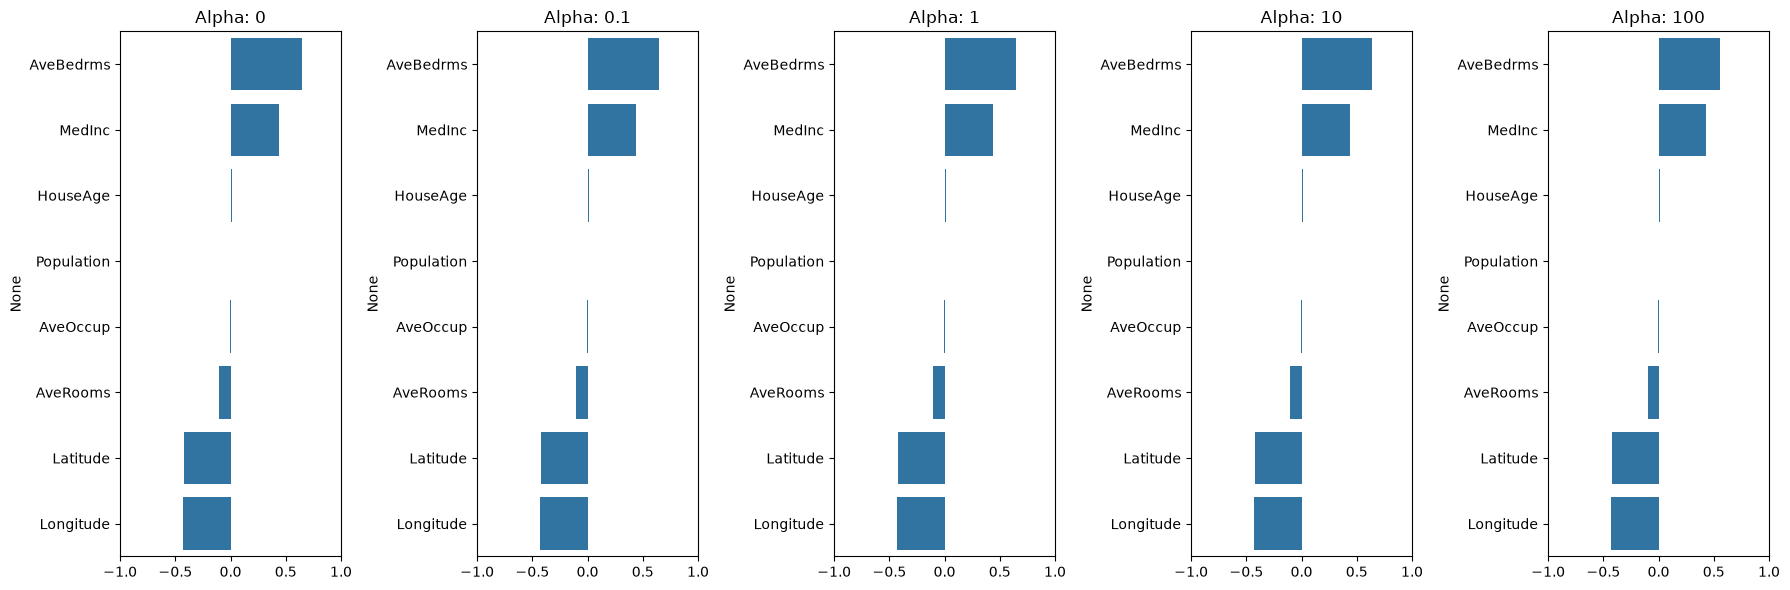

In [120]:
fig, axs = plt.subplots(figsize = (18, 6), nrows = 1, ncols = 5)

coeff_df = pd.DataFrame()

for pos, alpha in enumerate(alphas):
    ridge = Ridge(alpha = alpha)
    ridge.fit(X_data, y_target)

    coeff = pd.Series(data = ridge.coef_, index = X_data.columns)
    colname = "Alpha: " + str(alpha)
    coeff_df[colname] = coeff
    coeff = coeff.sort_values(ascending=False)

    axs[pos].set_title(colname)
    axs[pos].set_xlim(-1, 1)

    sns.barplot(x = coeff.values, y = coeff.index, ax = axs[pos])

plt.tight_layout()
plt.show()

In [121]:
ridge_alphas = [0, 0.1, 1, 10, 100]
sort_column = "Alpha: " + str(ridge_alphas[0])
coeff_df.sort_values(by = sort_column, ascending=False)

,Alpha: 0,Alpha: 0.1,Alpha: 1,Alpha: 10,Alpha: 100
AveBedrms,0.645066,0.644965,0.644062,0.635174,0.558249
MedInc,0.436693,0.436683,0.436594,0.435719,0.428210
HouseAge,0.009436,0.009436,0.009437,0.009452,0.009592
Population,-0.000004,-0.000004,-0.000004,-0.000004,-0.000003
AveOccup,-0.003787,-0.003787,-0.003786,-0.003785,-0.003773
AveRooms,-0.107322,-0.107303,-0.107133,-0.105456,-0.091012
Latitude,-0.421314,-0.421313,-0.421299,-0.421156,-0.419061
Longitude,-0.434514,-0.434511,-0.434485,-0.434217,-0.430993


In [125]:
from sklearn.linear_model import Lasso, ElasticNet

def get_linear_reg_eval(model_name, params = None, X_data_n = None, y_target_n = None, verbose = True, return_coeff = True):

    coeff_df = pd.DataFrame()
    if verbose : print("######", model_name, "######")

    for param in params:
        if model_name == "Ridge": model = Ridge(alpha = param)
        elif model_name == "Lasso": model = Lasso(alpha = param)
        elif model_name == "ElasticNet":
            model = ElasticNet(alpha = param, l1_ratio = 0.87)

        neg_mse_scores = cross_val_score(model, X_data_n, y_target_n, scoring = "neg_mean_squared_error", cv = 5)
        avg_rmse = np.mean(np.sqrt(-1 * neg_mse_scores))
        
        print("alpha {0} RMSE {1}".format(param, avg_rmse))

        model.fit(X_data_n, y_target_n)

        if return_coeff:
            coeff = pd.Series(data = model.coef_, index = X_data_n.columns)
            colname = "alpha: " + str(param)
            coeff_df[colname] = coeff

    return coeff_df
    

In [126]:
lasso_alphas = [0.07, 0.1, 0.5, 1, 3]

coeff_lasso_df = get_linear_reg_eval("Lasso", params = lasso_alphas, X_data_n = X_data, y_target_n = y_target)

###### Lasso ######
alpha 0.07 RMSE 0.7843330816065585
alpha 0.1 RMSE 0.8126415820543167
alpha 0.5 RMSE 0.8726693609660868
alpha 1 RMSE 0.999589987374003
alpha 3 RMSE 1.1710496863773499


In [127]:
sort_column = "alpha: " + str(lasso_alphas[0])
coeff_lasso_df.sort_values(by = sort_column, ascending=False)

,alpha: 0.07,alpha: 0.1,alpha: 0.5,alpha: 1,alpha: 3
MedInc,0.387057,0.390583,0.288855,0.145469,0.000000
HouseAge,0.013391,0.015082,0.012031,0.005815,0.000000
Population,0.000010,0.000018,0.000012,-0.000006,-0.000023
AveRooms,-0.000000,-0.000000,0.000000,0.000000,0.000000
AveBedrms,0.000000,0.000000,-0.000000,0.000000,0.000000
AveOccup,-0.003409,-0.003323,-0.000000,-0.000000,-0.000000
Longitude,-0.204689,-0.099225,-0.000000,-0.000000,0.000000
Latitude,-0.212806,-0.114214,-0.000000,-0.000000,0.000000


In [ ]:
# ElasticNet

elastic_alphas = [0.07, 0.1, 0.5, 1, 3]

coeff_elastic_df = get_linear_reg_eval("ElasticNet", params = elastic_alphas, X_data_n = X_data, y_target_n = y_target)

In [ ]:
sort_column = "alpha: " + str(elastic_alphas[0])
coeff_elastic_df.sort_values(by = sort_column, ascending=False)